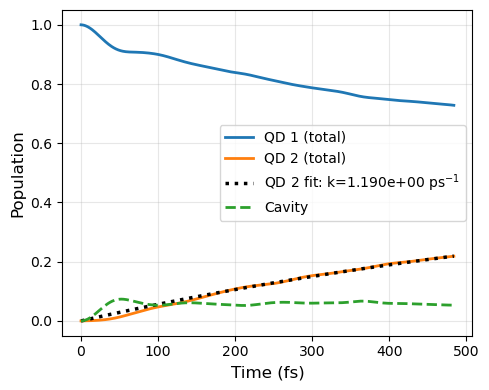

Max populations:
  QD 1: 1
  QD 2: 0.218573
  Cavity: 0.0735618

QD2 exponential-rise fit:
  P_inf = 0.5
  k     = 1.190284e+00 ps^-1
  tau   = 0.840135 ps

Total population (should be ~1): 1


In [4]:
#!/usr/bin/env python3
"""
Read and plot population data from pop.out.

State ordering for this TC example:
- States 0-3: QD 1 exciton states
- States 4-7: QD 2 exciton states
- State 8: cavity photon state
"""

import numpy as np
import matplotlib.pyplot as plt

autos = 2.4188843265857e-17
n_qd = 2
nstate_per_qd = 4
n_cavity = 1
n_qd_states = n_qd * nstate_per_qd

data = np.loadtxt("pop.out")
time = data[:, 0] * autos * 1e15  # au to fs
populations = data[:, 1:]
n_states = populations.shape[1]

if n_states != n_qd_states + n_cavity:
    raise ValueError(f"Expected {n_qd_states + n_cavity} states, found {n_states}")

# Extract QD and cavity populations
qd_pop = populations[:, :n_qd_states]
cavity_pop = populations[:, n_qd_states:]

# Sum population for each QD (across its nstate_per_qd states)
qd_total_pop = np.zeros((len(time), n_qd))
for qd in range(n_qd):
    start_idx = qd * nstate_per_qd
    end_idx = (qd + 1) * nstate_per_qd
    qd_total_pop[:, qd] = qd_pop[:, start_idx:end_idx].sum(axis=1)

# Fit QD2 population increase to P(t) = P_final * (1 - exp(-k t)).
# This constrained form starts from zero and fixes the final population to 0.5.
qd2_pop = qd_total_pop[:, 1]
p_inf_fit = 0.5
fit_mask = (time > time[0]) & np.isfinite(qd2_pop) & (qd2_pop < p_inf_fit)
t_fit = time[fit_mask]
y_fit = qd2_pop[fit_mask]

if len(t_fit) == 0:
    raise RuntimeError("No valid QD2 population points below P_final for exponential fit")

scaled_residual = 1.0 - y_fit / p_inf_fit
log_residual = np.log(scaled_residual)
k_fit = -np.sum(t_fit * log_residual) / np.sum(t_fit**2)

if k_fit <= 0.0:
    raise RuntimeError("Could not fit QD2 population to an exponential increase")

k_ps = k_fit * 1000.0  # fs^-1 -> ps^-1
tau_ps = 1.0 / k_ps
qd2_fit = p_inf_fit * (1.0 - np.exp(-k_fit * time))

fig, ax = plt.subplots(figsize=(5, 4))

# Plot total population for each QD
for qd in range(n_qd):
    ax.plot(time, qd_total_pop[:, qd], label=f"QD {qd + 1} (total)", linewidth=2)

ax.plot(time, qd2_fit, "k:", linewidth=2.5, label=f"QD 2 fit: k={k_ps:.3e} ps$^{{-1}}$")

# Plot cavity population
ax.plot(time, cavity_pop[:, 0], label="Cavity", linewidth=2, linestyle='--')

ax.set_xlabel("Time (fs)", fontsize=12)
ax.set_ylabel("Population", fontsize=12)
#ax.set_title("Population dynamics: QD states and cavity", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Max populations:")
for qd in range(n_qd):
    print(f"  QD {qd + 1}: {qd_total_pop[:, qd].max():.6g}")
print(f"  Cavity: {cavity_pop[:, 0].max():.6g}")
print("\nQD2 exponential-rise fit:")
print(f"  P_inf = {p_inf_fit:.6g}")
print(f"  k     = {k_ps:.6e} ps^-1")
print(f"  tau   = {tau_ps:.6g} ps")
print(f"\nTotal population (should be ~1): {(qd_total_pop.sum(axis=1) + cavity_pop.sum(axis=1)).mean():.6g}")


In [3]:
x=np.load("tc_params_AU.npz")
autoev= 27.2114079527
ham_sys=np.array(x['ham_sys_AU'])*autoev
ham_sys[:,0]*1000

array([ 2.04071025e+03,  1.01487419e-04, -1.64098354e-05, -6.01440651e-07,
        1.07107531e-01,  2.23923380e-04,  3.38723860e-06,  1.24146461e-07,
        9.99999999e+00])